<a href="https://colab.research.google.com/github/AMJAMAITHILI/DL_LAB/blob/main/WEEK6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing required libraries and MNIST dataset

In [ ]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255


In [ ]:
Y_train = to_categorical(y_train, 10)
Y_test = to_categorical(y_test, 10)

model = Sequential()
model.add(Conv2D(25, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu', input_shape=(28,28,1)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(50, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_test, Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 89ms/step - accuracy: 0.9226 - loss: 0.2588 - val_accuracy: 0.9789 - val_loss: 0.0666
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.9779 - loss: 0.0729 - val_accuracy: 0.9868 - val_loss: 0.0410
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.9837 - loss: 0.0535 - val_accuracy: 0.9890 - val_loss: 0.0334
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 85ms/step - accuracy: 0.9868 - loss: 0.0422 - val_accuracy: 0.9904 - val_loss: 0.0313
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 44s 93ms/step - accuracy: 0.9894 - loss: 0.0354 - val_accuracy: 0.9880 - val_loss: 0.0341
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 79s 87ms/step - accuracy: 0.9909 - loss: 0.0294 - val_accuracy: 0.9920 - val_loss: 0.0253
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - accuracy: 0.9921 - loss: 0.0260 - val_accuracy: 0.9904 - val_loss: 0.0291
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.9930 - loss: 0.0228 - 

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, Y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0299
Test Accuracy: 0.9916


To make predictions using the trained model on the X_test dataset. This involves using the `predict` method and converting the probability outputs to class labels.



In [ ]:
import numpy as np
y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

print("Shape of prediction probabilities:", y_pred_probs.shape)
print("Shape of predicted labels:", y_pred_labels.shape)
print("First 10 predicted probability vectors:\n", y_pred_probs[:10])
print("First 10 predicted labels:\n", y_pred_labels[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Shape of prediction probabilities: (10000, 10)
Shape of predicted labels: (10000,)
First 10 predicted probability vectors:
 [[8.65949268e-09 4.96229234e-07 6.48474554e-07 3.35736217e-06
  8.69058780e-08 2.06042312e-08 6.10449052e-11 9.99992192e-01
  1.30422237e-07 3.07220671e-06]
 [7.76184334e-06 4.01731114e-07 9.99991357e-01 2.32918324e-10
  2.20167315e-08 9.49199486e-12 2.20535185e-07 1.28212407e-09
  2.78508622e-07 1.79369491e-10]
 [1.08226935e-07 9.99868631e-01 2.18881974e-06 2.94731861e-09
  1.03376951e-04 6.53607003e-07 2.15446607e-06 1.86234829e-05
  3.75912191e-06 5.33981222e-07]
 [9.99809265e-01 2.21027552e-08 1.03999599e-04 1.50509294e-09
  5.04621624e-08 1.78015421e-06 6.78395736e-05 4.77750245e-06
  3.86469128e-06 8.38617780e-06]
 [3.06983522e-10 1.79827631e-09 5.16637257e-08 1.22105481e-09
  9.99997318e-01 2.47389687e-09 4.31976268e-08 2.02589145e-08
  2.12914610e-08 2.43219915e-06]
 [4.05414333e-08 9.99938428e-01 7.18731997e-07 1.

Now we try to visualize some sample images from the X_test dataset along with their true and predicted labels to better understand the model's performance qualitatively. This involves selecting a few images, retrieving their true and predicted labels, and displaying them using matplotlib.



Displaying sample predictions:


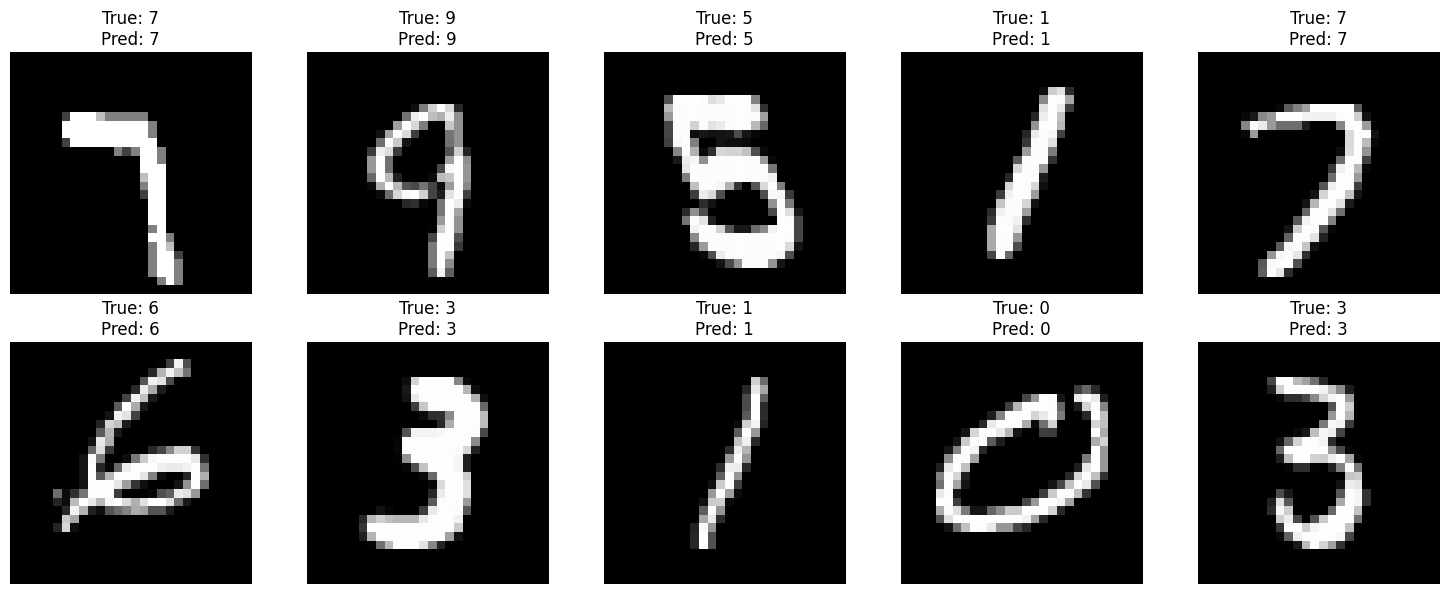

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf # Added tensorflow import

# Get true labels from Y_test (which is one-hot encoded)
y_true_labels = np.argmax(Y_test, axis=1)

def plot_predictions(images, true_labels, predicted_labels, num_samples=10):
    plt.figure(figsize=(15, 6))
    for i in range(num_samples):
        # Choose random indices to display
        idx = np.random.randint(0, len(images))
        plt.subplot(2, num_samples // 2, i + 1) # Changed num_samples/2 to num_samples // 2
        plt.imshow(tf.squeeze(images[idx]), cmap='gray')
        plt.title(f"True: {true_labels[idx]}\nPred: {predicted_labels[idx]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("Displaying sample predictions:")
plot_predictions(X_test, y_true_labels, y_pred_labels, num_samples=10)

In [ ]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.4768 - loss: 1.4850 - val_accuracy: 0.5557 - val_loss: 1.2676
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5740 - loss: 1.2235 - val_accuracy: 0.5699 - val_loss: 1.2262
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.6081 - loss: 1.1282 - val_accuracy: 0.5979 - val_loss: 1.1540
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6328 - loss: 1.0623 - val_accuracy: 0.6134 - val_loss: 1.1091
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.6508 - loss: 1.0148 - val_accuracy: 0.6215 - val_loss: 1.0953


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Displaying sample predictions:


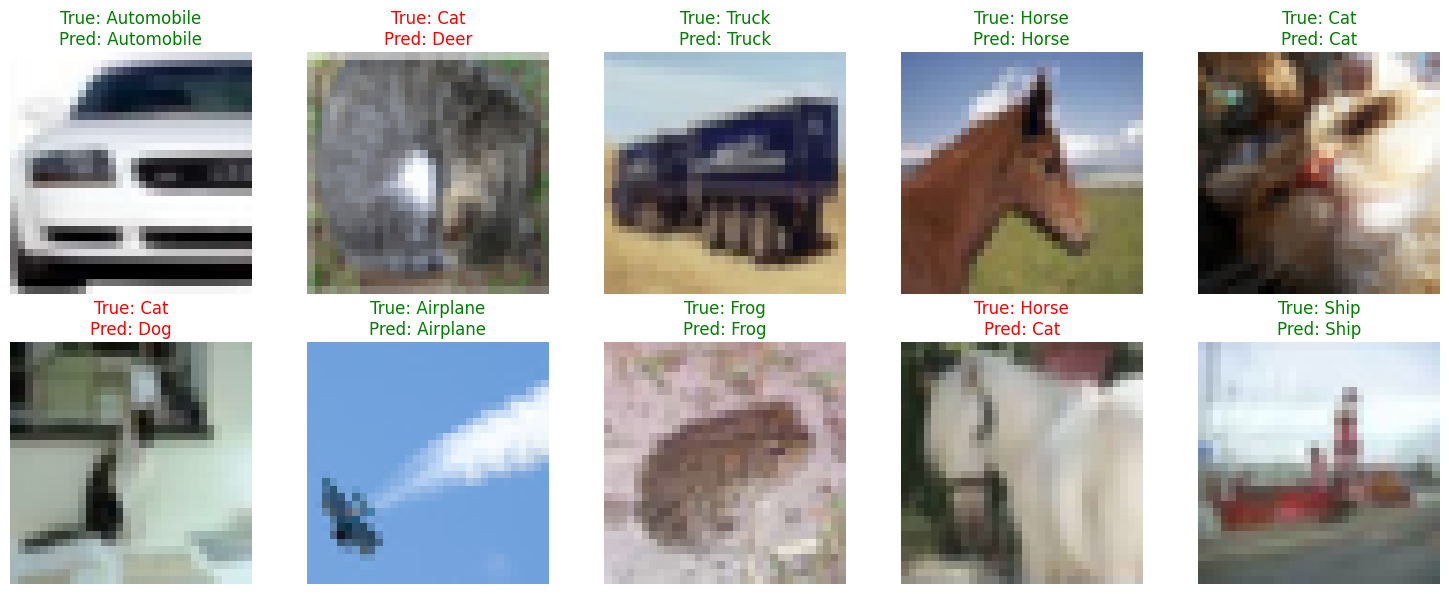

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Predictions
y_pred = model.predict(x_test)

# Convert probabilities → labels
y_pred_labels = np.argmax(y_pred, axis=1)

# Convert y_test shape (10000,1) → (10000,)
y_true_labels = y_test.flatten()

# CIFAR-10 class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

def plot_predictions(images, true_labels, predicted_labels, num_samples=10):
    plt.figure(figsize=(15, 6))

    for i in range(num_samples):
        idx = np.random.randint(0, len(images))

        plt.subplot(2, num_samples // 2, i + 1)

        plt.imshow(images[idx])

        true = class_names[true_labels[idx]]
        pred = class_names[predicted_labels[idx]]

        color = 'green' if true_labels[idx] == predicted_labels[idx] else 'red'

        plt.title(f"True: {true}\nPred: {pred}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("Displaying sample predictions:")
plot_predictions(x_test, y_true_labels, y_pred_labels, num_samples=10)

**IMPROVING ACCURACY BY ADDING DROPOUT REGULARIZATION TECHNIQUE AND MODIFYING NO OF LAYERS USED**

In [ ]:

# 1. Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 2. Load Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)
# 4. CNN Model (Optimized)
model = Sequential([
    Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# 5. Train Model
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(x_test, y_test)
)

# 6. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# 7. Predictions
y_pred = model.predict(x_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = y_test.flatten()

# 8. Class Names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# 9. Visualization Function
def plot_predictions(images, true_labels, predicted_labels, num_samples=10):
    plt.figure(figsize=(15, 6))

    for i in range(num_samples):
        idx = np.random.randint(0, len(images))

        plt.subplot(2, num_samples // 2, i + 1)
        plt.imshow(images[idx])

        true = class_names[true_labels[idx]]
        pred = class_names[predicted_labels[idx]]

        color = 'green' if true_labels[idx] == predicted_labels[idx] else 'red'

        plt.title(f"True: {true}\nPred: {pred}", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 10.Predictions
print("Sample Predictions:")
plot_predictions(x_test, y_true_labels, y_pred_labels, num_samples=10)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 310s 392ms/step - accuracy: 0.2519 - loss: 1.9708 - val_accuracy: 0.3840 - val_loss: 1.6953
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 325s 397ms/step - accuracy: 0.3615 - loss: 1.7040 - val_accuracy: 0.4459 - val_loss: 1.5734
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 286s 366ms/step - accuracy: 0.4383 - loss: 1.5364 - val_accuracy: 0.5269 - val_loss: 1.3274
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 283s 361ms/step - accuracy: 0.4866 - loss: 1.4159 - val_accuracy: 0.5487 - val_loss: 1.3299
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 288s 369ms/step - accuracy: 0.5234 - loss: 1.3416 - val_accuracy: 0.5428 - val_loss: 1.3131
Epoch 6/20
105/782 ━━━━━━━━━━━━━━━━━━━━ 4:16 378ms/step - accuracy: 0.5299 - loss: 1.3413